In [9]:
# Cell 1: Import Libraries
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, models, transforms
from torchvision.models import resnet50, efficientnet_b0
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.metrics import accuracy_score
import time
import copy

# Check if GPU is available
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:0


In [10]:
# Cell 2: Data Preprocessing and Loading
# Define data transformations
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomRotation(20),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load datasets
data_dir = '/content/drive/MyDrive/multi_leaf'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x])
                  for x in ['train', 'valid']}
dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=True, num_workers=4)
               for x in ['train', 'valid']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
class_names = image_datasets['train'].classes

print(f"Classes: {class_names}")
print(f"Training samples: {dataset_sizes['train']}")
print(f"Validation samples: {dataset_sizes['valid']}")

Classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy']
Training samples: 4386
Validation samples: 5198


In [11]:
# Cell 3: Model Selection and Preparation
# Function to create a model
def create_model(model_name, num_classes):
    if model_name == 'resnet50':
        model = models.resnet50(pretrained=True)
        num_ftrs = model.fc.in_features
        model.fc = nn.Linear(num_ftrs, num_classes)
    elif model_name == 'efficientnet':
        model = models.efficientnet_b0(pretrained=True)
        num_ftrs = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)
    else:
        raise ValueError("Model not supported")

    model = model.to(device)
    return model

# Number of classes
num_classes = len(class_names)

# Create models
resnet_model = create_model('resnet50', num_classes)
efficientnet_model = create_model('efficientnet', num_classes)

# Loss function and optimizers
criterion = nn.CrossEntropyLoss()

# Optimizers with different learning rates
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=0.001, weight_decay=1e-4)
efficientnet_optimizer = optim.Adam(efficientnet_model.parameters(), lr=0.001, weight_decay=1e-4)

# Learning rate schedulers
resnet_scheduler = ReduceLROnPlateau(resnet_optimizer, mode='max', factor=0.1, patience=3)
efficientnet_scheduler = ReduceLROnPlateau(efficientnet_optimizer, mode='max', factor=0.1, patience=3)

In [12]:
# Cell 4: Training Function
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    # Track history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'valid']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]

            # Update history
            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())
                scheduler.step(epoch_acc)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            # Deep copy the model if validation accuracy improves
            if phase == 'valid' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

In [13]:
# Cell 5: Train ResNet50
print("Training ResNet50...")
resnet_model, resnet_history = train_model(
    resnet_model, dataloaders, criterion, resnet_optimizer, resnet_scheduler, num_epochs=10
)

# Save the best model
torch.save(resnet_model.state_dict(), 'best_resnet_model.pth')
print("ResNet50 model saved as 'best_resnet_model.pth'")

Training ResNet50...
Epoch 1/10
----------
train Loss: 1.0880 Acc: 0.6452
valid Loss: 0.5115 Acc: 0.8197

Epoch 2/10
----------
train Loss: 0.5547 Acc: 0.8190
valid Loss: 0.2137 Acc: 0.9325

Epoch 3/10
----------
train Loss: 0.4691 Acc: 0.8456
valid Loss: 0.4064 Acc: 0.8523

Epoch 4/10
----------
train Loss: 0.4237 Acc: 0.8568
valid Loss: 0.5760 Acc: 0.8430

Epoch 5/10
----------
train Loss: 0.4646 Acc: 0.8493
valid Loss: 0.1878 Acc: 0.9388

Epoch 6/10
----------
train Loss: 0.3969 Acc: 0.8650
valid Loss: 0.1098 Acc: 0.9638

Epoch 7/10
----------
train Loss: 0.3474 Acc: 0.8860
valid Loss: 0.1121 Acc: 0.9611

Epoch 8/10
----------
train Loss: 0.3164 Acc: 0.8931
valid Loss: 0.2261 Acc: 0.9342

Epoch 9/10
----------
train Loss: 0.2774 Acc: 0.9083
valid Loss: 0.0996 Acc: 0.9642

Epoch 10/10
----------
train Loss: 0.3249 Acc: 0.8871
valid Loss: 0.1014 Acc: 0.9681

Training complete in 12m 56s
Best val Acc: 0.9681
ResNet50 model saved as 'best_resnet_model.pth'


In [14]:
# Cell 6: Train EfficientNet-B0
print("Training EfficientNet-B0...")
efficientnet_model, efficientnet_history = train_model(
    efficientnet_model, dataloaders, criterion, efficientnet_optimizer, efficientnet_scheduler, num_epochs=10
)

# Save the best model
torch.save(efficientnet_model.state_dict(), 'best_efficientnet_model.pth')
print("EfficientNet-B0 model saved as 'best_efficientnet_model.pth'")

Training EfficientNet-B0...
Epoch 1/10
----------
train Loss: 0.5717 Acc: 0.8176
valid Loss: 0.2234 Acc: 0.9354

Epoch 2/10
----------
train Loss: 0.2802 Acc: 0.9065
valid Loss: 0.1445 Acc: 0.9552

Epoch 3/10
----------
train Loss: 0.2636 Acc: 0.9181
valid Loss: 0.0862 Acc: 0.9750

Epoch 4/10
----------
train Loss: 0.1954 Acc: 0.9378
valid Loss: 0.0822 Acc: 0.9735

Epoch 5/10
----------
train Loss: 0.1847 Acc: 0.9407
valid Loss: 0.0656 Acc: 0.9800

Epoch 6/10
----------
train Loss: 0.1830 Acc: 0.9380
valid Loss: 0.0574 Acc: 0.9808

Epoch 7/10
----------
train Loss: 0.1769 Acc: 0.9384
valid Loss: 0.0393 Acc: 0.9863

Epoch 8/10
----------
train Loss: 0.1711 Acc: 0.9412
valid Loss: 0.0510 Acc: 0.9808

Epoch 9/10
----------
train Loss: 0.1669 Acc: 0.9425
valid Loss: 0.0514 Acc: 0.9823

Epoch 10/10
----------
train Loss: 0.1860 Acc: 0.9373
valid Loss: 0.0476 Acc: 0.9833

Training complete in 11m 54s
Best val Acc: 0.9863
EfficientNet-B0 model saved as 'best_efficientnet_model.pth'


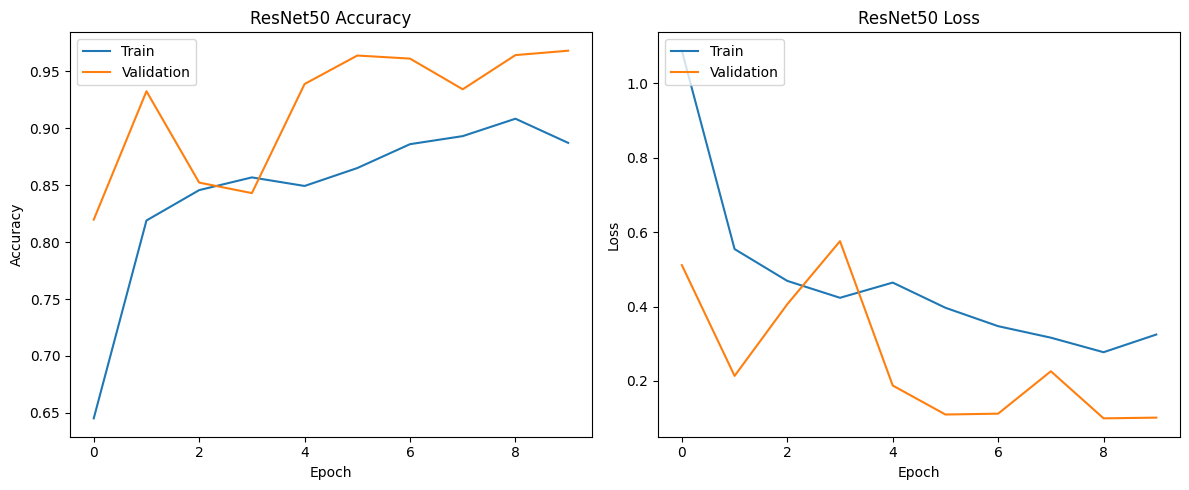

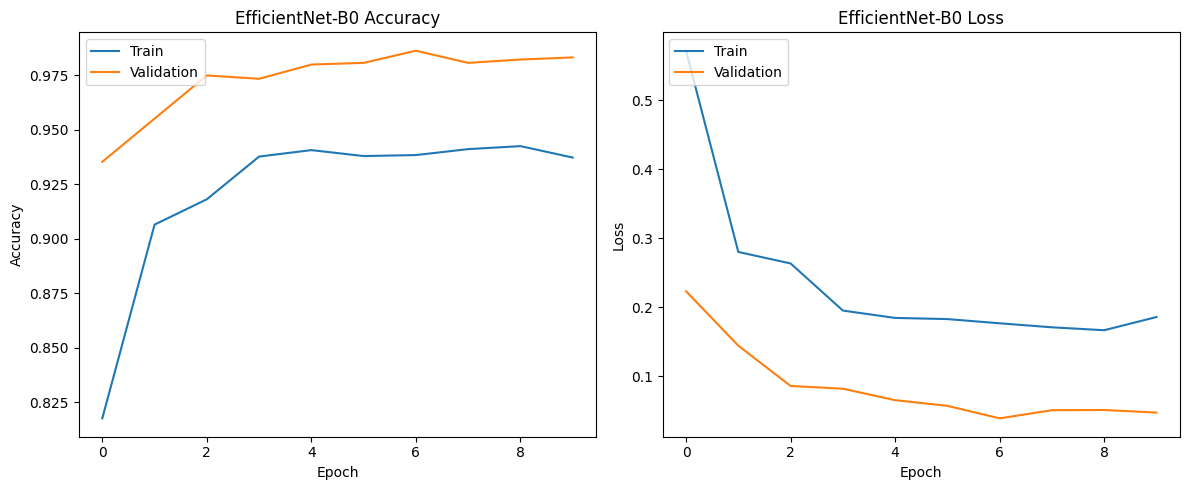

In [15]:
# Cell 7: Plot Learning Curves
def plot_history(history, model_name):
    plt.figure(figsize=(12, 5))

    # Plot training & validation accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history['train_acc'], label='Train')
    plt.plot(history['val_acc'], label='Validation')
    plt.title(f'{model_name} Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    # Plot training & validation loss
    plt.subplot(1, 2, 2)
    plt.plot(history['train_loss'], label='Train')
    plt.plot(history['val_loss'], label='Validation')
    plt.title(f'{model_name} Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

# Plot ResNet50 history
plot_history(resnet_history, 'ResNet50')

# Plot EfficientNet history
plot_history(efficientnet_history, 'EfficientNet-B0')

In [16]:
# Cell 8: Evaluate Models on Validation Set
def evaluate_model(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = accuracy_score(all_labels, all_preds)
    return accuracy

# Evaluate ResNet50
resnet_accuracy = evaluate_model(resnet_model, dataloaders['valid'])
print(f'ResNet50 Validation Accuracy: {resnet_accuracy:.4f}')

# Evaluate EfficientNet
efficientnet_accuracy = evaluate_model(efficientnet_model, dataloaders['valid'])
print(f'EfficientNet-B0 Validation Accuracy: {efficientnet_accuracy:.4f}')

# Determine best model
if resnet_accuracy > efficientnet_accuracy:
    best_model_name = 'ResNet50'
    best_model_path = 'best_resnet_model.pth'
else:
    best_model_name = 'EfficientNet-B0'
    best_model_path = 'best_efficientnet_model.pth'

print(f"\nBest performing model: {best_model_name} with accuracy: {max(resnet_accuracy, efficientnet_accuracy):.4f}")

ResNet50 Validation Accuracy: 0.9681


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


EfficientNet-B0 Validation Accuracy: 0.9863

Best performing model: EfficientNet-B0 with accuracy: 0.9863


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Prediction: Corn_(maize)___Common_rust_
Confidence: 1.0000


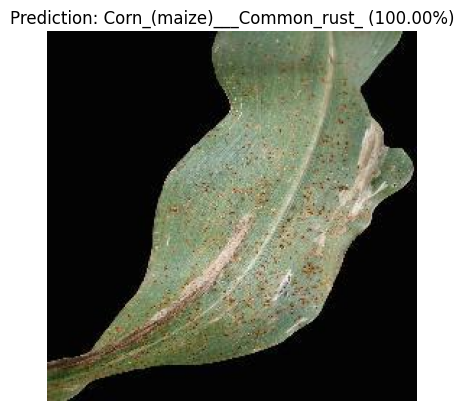

In [17]:
# Cell 9: Load Best Model and Predict on a Single Image
# Load the best model
if best_model_name == 'ResNet50':
    best_model = create_model('resnet50', num_classes)
else:
    best_model = create_model('efficientnet', num_classes)

best_model.load_state_dict(torch.load(best_model_path))
best_model = best_model.to(device)
best_model.eval()

# Function to predict a single image
def predict_image(image_path, model, class_names):
    # Load and preprocess the image
    image = Image.open(image_path)
    preprocess = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    image_tensor = preprocess(image).unsqueeze(0).to(device)

    # Make prediction
    with torch.no_grad():
        outputs = model(image_tensor)
        _, preds = torch.max(outputs, 1)

    # Get class name and confidence
    class_idx = preds.item()
    class_name = class_names[class_idx]
    confidence = torch.nn.functional.softmax(outputs, dim=1)[0][class_idx].item()

    return class_name, confidence

# Example usage (replace with your image path)
sample_image_path = '/content/drive/MyDrive/multi_leaf/valid/Corn_(maize)___Common_rust_/RS_Rust 1564_flipLR.JPG'  # Replace with actual path

if os.path.exists(sample_image_path):
    prediction, confidence = predict_image(sample_image_path, best_model, class_names)
    print(f"Prediction: {prediction}")
    print(f"Confidence: {confidence:.4f}")

    # Display the image
    img = Image.open(sample_image_path)
    plt.imshow(img)
    plt.title(f"Prediction: {prediction} ({confidence:.2%})")
    plt.axis('off')
    plt.show()
else:
    print(f"Sample image not found at {sample_image_path}")
    print("Please update the path to a valid image file.")